In [1]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

In [5]:
PROJECT_ROOT = Path.cwd().parent

IMAGE_DIR = PROJECT_ROOT / "data" / "raw" / "Images"
CAPTION_FILE = (PROJECT_ROOT/ "data"/ "raw"/ "annotations"/ "Flickr8k.token.txt")

print("Image directory:", IMAGE_DIR)
print("Caption file:", CAPTION_FILE)

Image directory: /home/ec2-user/SageMaker/Image Caption Genator/Image-Caption-Generator/data/raw/Images
Caption file: /home/ec2-user/SageMaker/Image Caption Genator/Image-Caption-Generator/data/raw/annotations/Flickr8k.token.txt


In [6]:
captions_df = pd.read_csv(CAPTION_FILE, sep="\t", header=None, names=["caption_id", "caption"])

print(captions_df.head())
print("Shape:", captions_df.shape)
print("Columns:", captions_df.columns.tolist())

                    caption_id  \
0  1000268201_693b08cb0e.jpg#0   
1  1000268201_693b08cb0e.jpg#1   
2  1000268201_693b08cb0e.jpg#2   
3  1000268201_693b08cb0e.jpg#3   
4  1000268201_693b08cb0e.jpg#4   

                                             caption  
0  A child in a pink dress is climbing up a set o...  
1              A girl going into a wooden building .  
2   A little girl climbing into a wooden playhouse .  
3  A little girl climbing the stairs to her playh...  
4  A little girl in a pink dress going into a woo...  
Shape: (40460, 2)
Columns: ['caption_id', 'caption']


In [7]:
captions_df[["image", "caption_number"]] = (captions_df["caption_id"].str.rsplit("#", n=1, expand=True))

captions_df["caption_number"] = captions_df["caption_number"].astype(int)

captions_df = captions_df[["image", "caption_number", "caption"]]

print(captions_df.head())

                       image  caption_number  \
0  1000268201_693b08cb0e.jpg               0   
1  1000268201_693b08cb0e.jpg               1   
2  1000268201_693b08cb0e.jpg               2   
3  1000268201_693b08cb0e.jpg               3   
4  1000268201_693b08cb0e.jpg               4   

                                             caption  
0  A child in a pink dress is climbing up a set o...  
1              A girl going into a wooden building .  
2   A little girl climbing into a wooden playhouse .  
3  A little girl climbing the stairs to her playh...  
4  A little girl in a pink dress going into a woo...  


In [8]:
image_files = list(IMAGE_DIR.glob("*.jpg"))

print("Number of image files:", len(image_files))
print("Number of unique captioned images:", captions_df["image"].nunique())
print("Missing captions:", captions_df["caption"].isna().sum())

Number of image files: 4424
Number of unique captioned images: 8092
Missing captions: 0


In [9]:
captions_per_image = captions_df.groupby("image").size()

print(captions_per_image.describe())
print(captions_per_image.value_counts())

count    8092.0
mean        5.0
std         0.0
min         5.0
25%         5.0
50%         5.0
75%         5.0
max         5.0
dtype: float64
5    8092
Name: count, dtype: int64


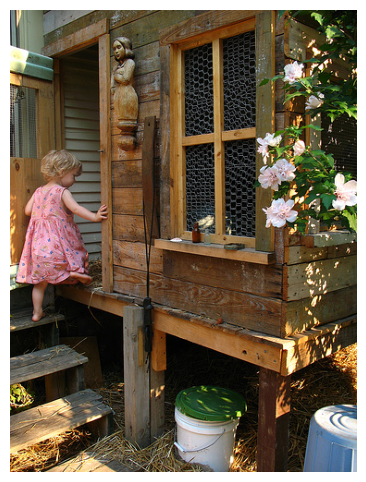

1. A child in a pink dress is climbing up a set of stairs in an entry way .
2. A girl going into a wooden building .
3. A little girl climbing into a wooden playhouse .
4. A little girl climbing the stairs to her playhouse .
5. A little girl in a pink dress going into a wooden cabin .


In [10]:
sample_image_name = captions_df["image"].iloc[0]
sample_image_path = IMAGE_DIR / sample_image_name

image = Image.open(sample_image_path)

plt.figure(figsize=(8, 6))
plt.imshow(image)
plt.axis("off")
plt.show()

sample_captions = captions_df.loc[
    captions_df["image"] == sample_image_name,
    "caption"
]

for number, caption in enumerate(sample_captions, start=1):
    print(f"{number}. {caption}")

In [15]:
def load_split(split_file):
    return set(
        pd.read_csv(
            split_file,
            header=None
        )[0].str.strip()
    )


train_images = load_split(
    ANNOTATION_DIR / "Flickr_8k.trainImages.txt"
)

validation_images = load_split(
    ANNOTATION_DIR / "Flickr_8k.devImages.txt"
)

test_images = load_split(
    ANNOTATION_DIR / "Flickr_8k.testImages.txt"
)


train_df = captions_df[
    captions_df["image"].isin(train_images)
].reset_index(drop=True)

validation_df = captions_df[
    captions_df["image"].isin(validation_images)
].reset_index(drop=True)

test_df = captions_df[
    captions_df["image"].isin(test_images)
].reset_index(drop=True)

In [16]:
print("Training images:", train_df["image"].nunique())
print("Validation images:", validation_df["image"].nunique())
print("Test images:", test_df["image"].nunique())

print("Training captions:", len(train_df))
print("Validation captions:", len(validation_df))
print("Test captions:", len(test_df))

Training images: 3288
Validation images: 529
Test images: 564
Training captions: 16440
Validation captions: 2645
Test captions: 2820
